# 16 · Showcase: the Machine's view

What the trained models see, drawn the way a surveillance system shows it: every subject bracketed and numbered, the thermal view beside the visible one, and a trust map of where CFFM-Net leaned on each camera. Then camera failures, a tracked street crossing, and your own images.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot`, LLVIP and M3FD, and the saved outputs of notebooks 05 and 07 |
| **Expected runtime** | about 10 minutes on one GPU |
| **Produces** | `results/showcase/`: every board as JPEG, a tracked clip as MP4 and GIF |

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


In [2]:
from pathlib import Path

import numpy as np, torch
from cffm import hud, showcase as sc
from cffm.train import _load
from cffm.viz import make_pair

for name in ("llvip", "m3fd"):
    pipeline.prepare(name, env, plan)
ckpts = pipeline.find_checkpoints(env)
dev = "cuda:0" if torch.cuda.is_available() else "cpu"
cffm = {n: _load(ckpts[f"{n}_cffm"]).to(dev) for n in ("llvip", "m3fd")}
concat = _load(ckpts["llvip_concat"]).to(dev)
from ultralytics import YOLO
coco = YOLO(str(env.weights / "yolo26n.pt"))
out = env.project / "results" / "showcase"
out.mkdir(parents=True, exist_ok=True)
print("device:", torch.cuda.get_device_name(0) if dev != "cpu" else "cpu")

device: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. One scene, three views

The most crowded night frame in LLVIP's test set. Left, the visible camera (brightened for display only); centre, thermal; right, the fusion trust map, blue where CFFM-Net weighted the visible stream and orange where it weighted thermal.

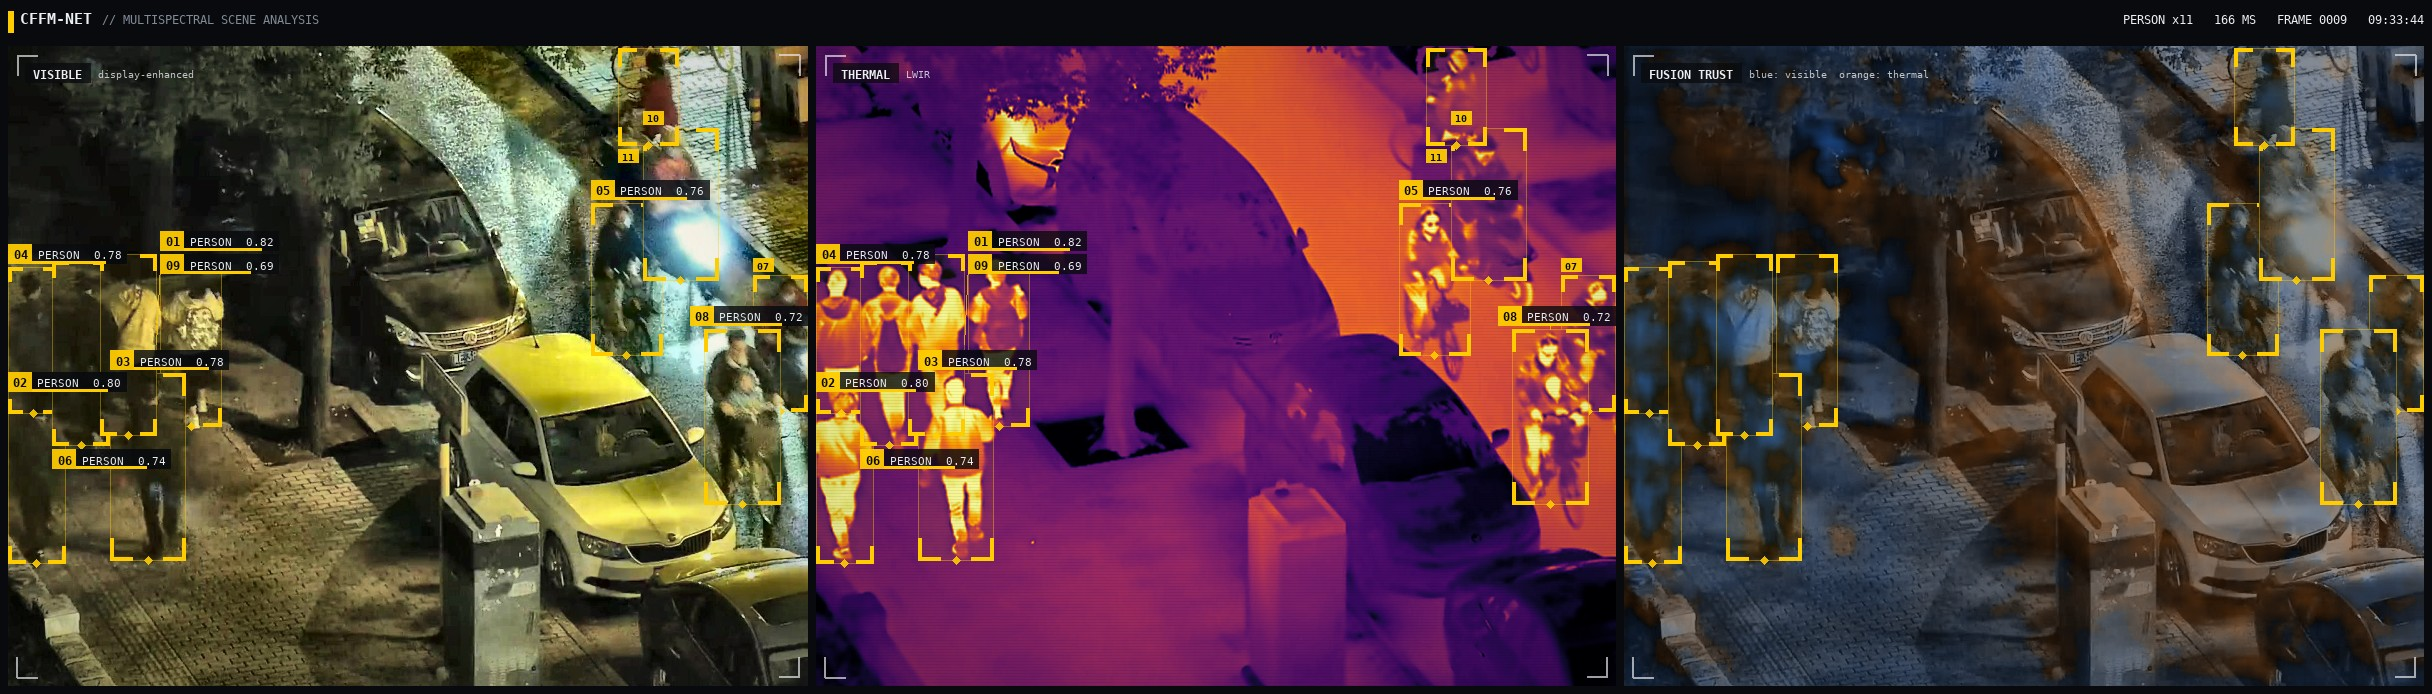

,class,conf,box px,thermal trust
subject,,,,
01,PERSON,0.821,98x275,0.48
02,PERSON,0.804,91x269,0.46
03,PERSON,0.782,119x298,0.47
04,PERSON,0.777,78x233,0.46
05,PERSON,0.760,113x243,0.48
06,PERSON,0.742,90x294,0.48
07,PERSON,0.720,86x217,0.50
08,PERSON,0.716,121x280,0.47
09,PERSON,0.694,90x288,0.43


In [3]:
stem = sc.crowded(env.data / "llvip", k=1)[0]
a = hud.analyze(cffm["llvip"], *sc.pair_paths(env, "llvip", stem), frame=int(stem) % 10000)
sc.show(a.board)
sc.save(a.board, out / "hero_llvip.jpg")
sc.subject_log(a.det, a.names, a.share)

## 2. Gallery

The four most crowded scenes of each test set, one per video sequence: night crossings from LLVIP and city traffic from M3FD (people, cars, buses, motorcycles, lamps, trucks).

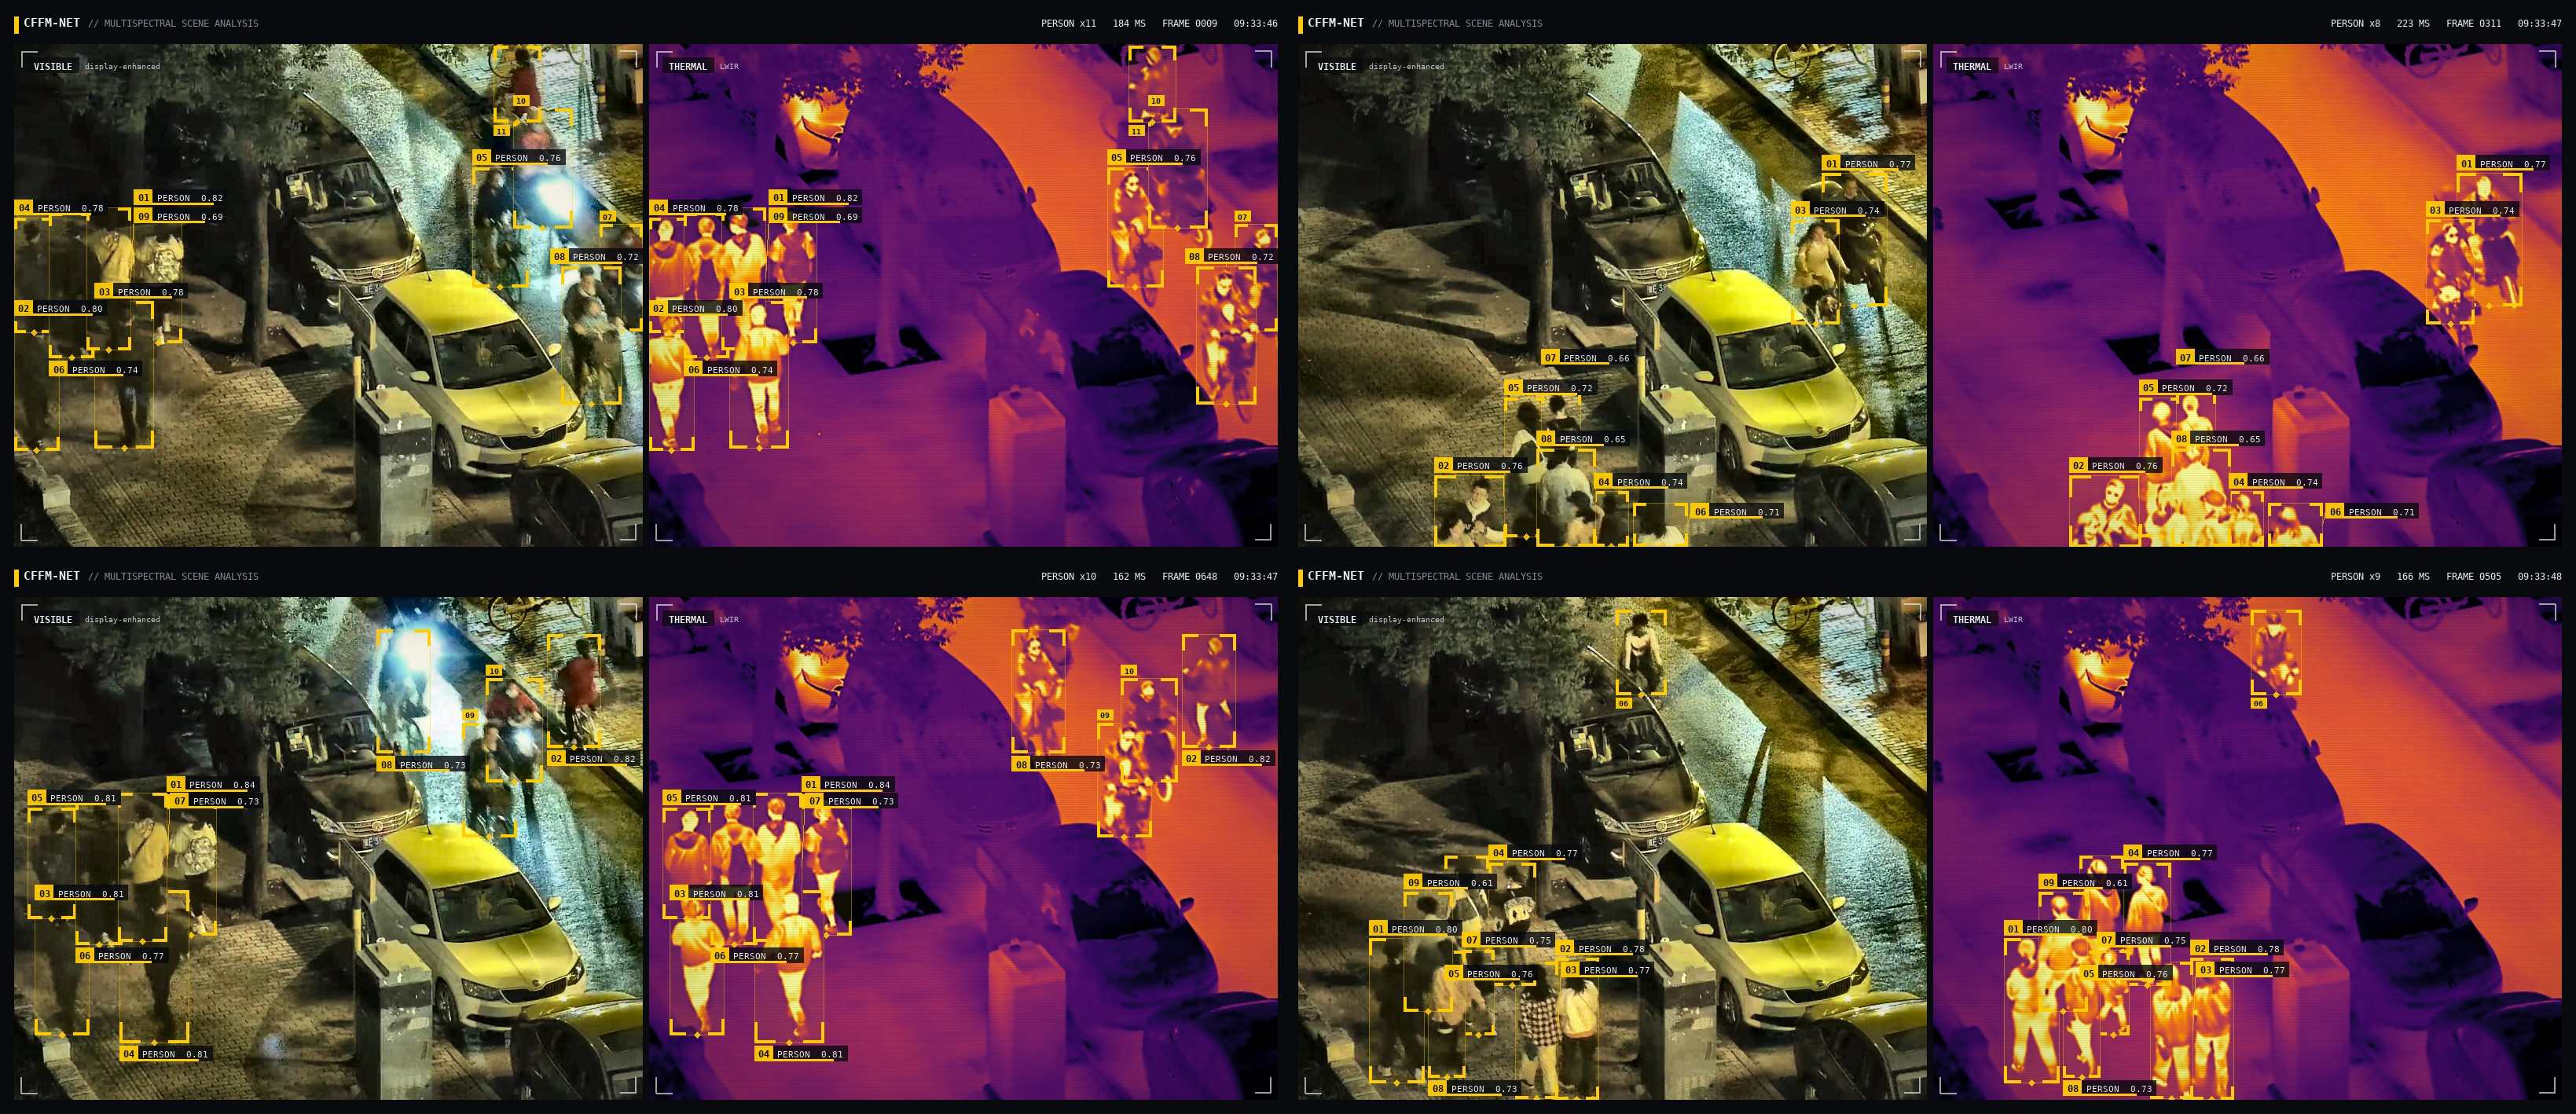

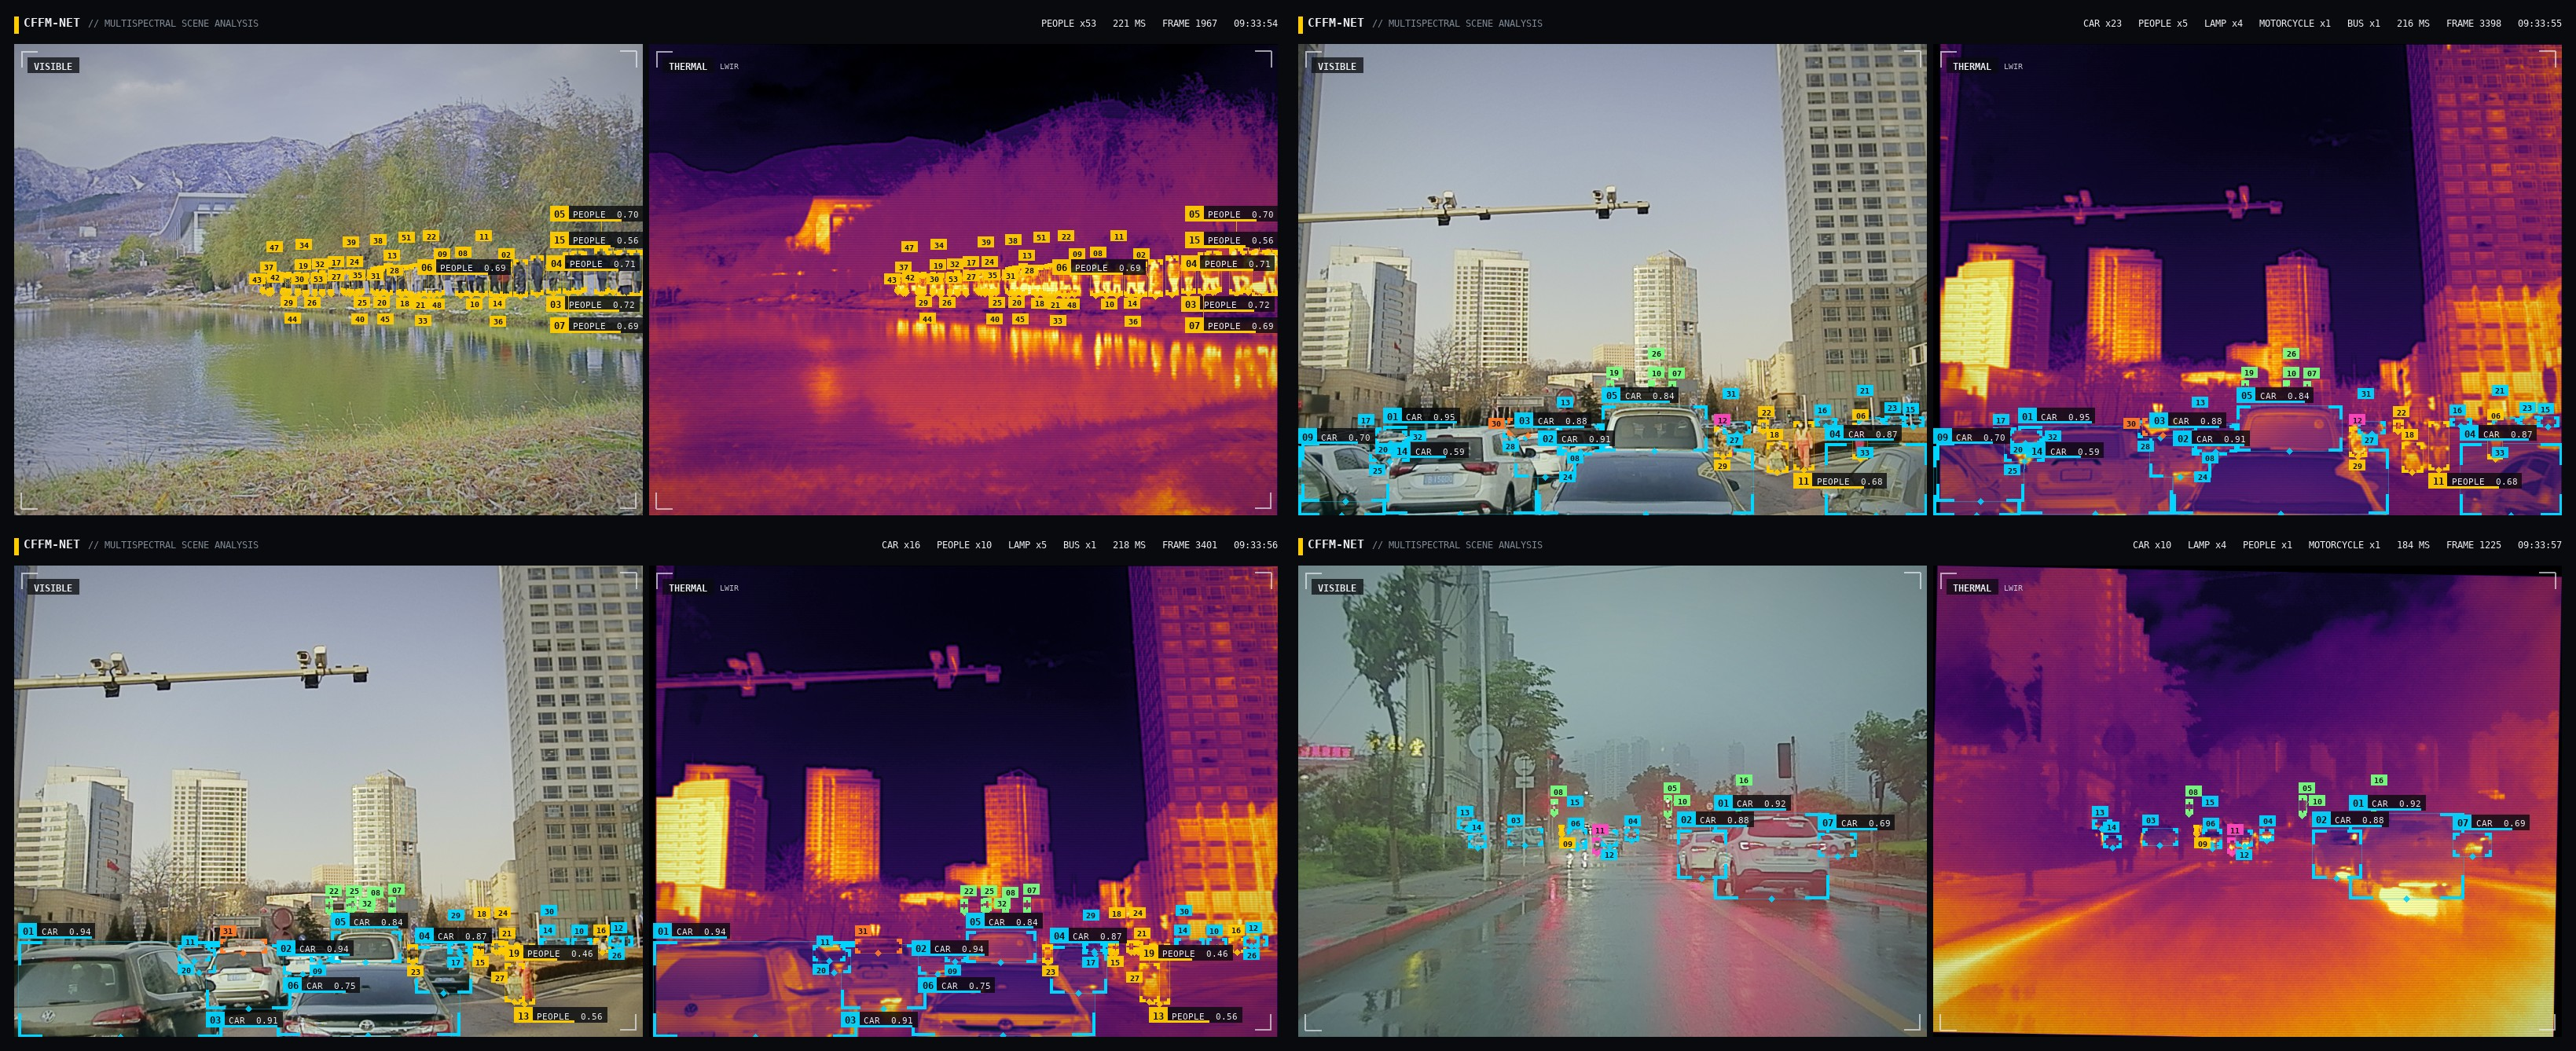

In [4]:
boards = []
for name in ("llvip", "m3fd"):
    for stem in sc.crowded(env.data / name, k=4):
        a = hud.analyze(cffm[name], *sc.pair_paths(env, name, stem), frame=int(stem) % 10000,
                        panels=("visible", "thermal"))
        sc.save(a.board, out / f"{name}_{stem}.jpg")
        boards.append(a.board)
sc.show(hud.grid(boards[:4], cols=2))
sc.show(hud.grid(boards[4:], cols=2))

## 3. Checked against the labels

Coloured brackets are detections, thin white boxes the human labels. A detection counts as a match at IoU 0.5 or more.

llvip 210058: 9 labels, 7 detections, 6 matched, 3 missed, 1 extra


m3fd 03659: 23 labels, 25 detections, 18 matched, 5 missed, 7 extra


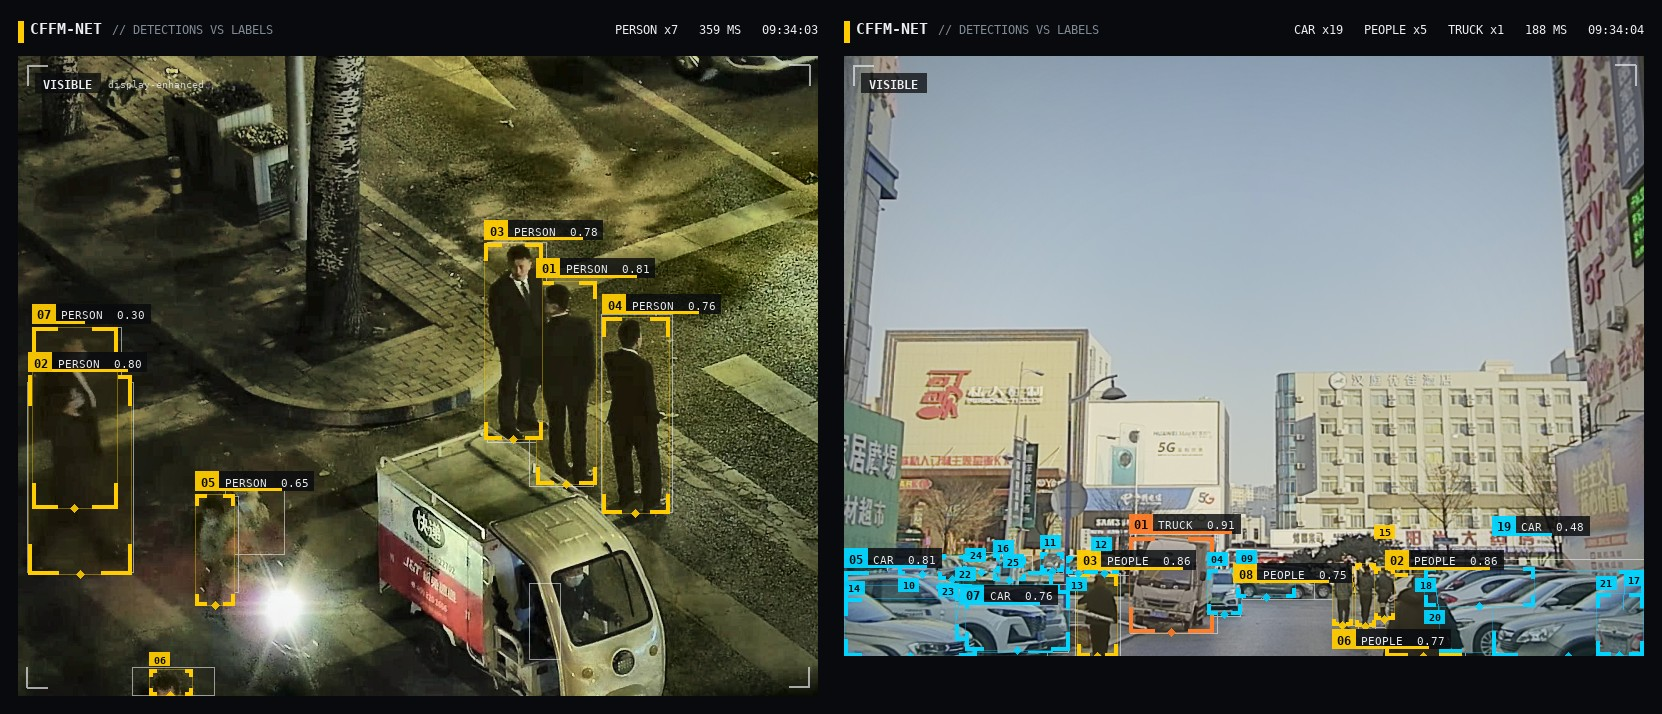

In [5]:
from scipy.optimize import linear_sum_assignment
boards = []
for name in ("llvip", "m3fd"):
    stem = sc.crowded(env.data / name, k=6)[5]
    pair = make_pair(*sc.pair_paths(env, name, stem))
    gt = sc.gt_boxes(env, name, stem, pair.shape)
    a = hud.analyze(cffm[name], pair, gt=gt, panels=("visible",), subtitle="DETECTIONS VS LABELS")
    iou = hud._iou(a.det[:, :4], gt[:, :4]) if len(a.det) and len(gt) else np.zeros((len(a.det), len(gt)))
    r, c = linear_sum_assignment(-iou) if iou.size else ([], [])
    tp = int(sum(iou[i, j] >= 0.5 for i, j in zip(r, c)))
    print(f"{name} {stem}: {len(gt)} labels, {len(a.det)} detections, {tp} matched, "
          f"{len(gt) - tp} missed, {len(a.det) - tp} extra")
    boards.append(a.board)
sc.show(hud.grid(boards, cols=2))

## 4. What the Machine trusts, by light level

Mean thermal share of the fusion weights against scene brightness, over 150 random test frames per dataset. If the gate works as intended, darker scenes should lean on thermal.

llvip: mean thermal share 0.510; corr(brightness, share) = -0.50
m3fd: mean thermal share 0.491; corr(brightness, share) = -0.49


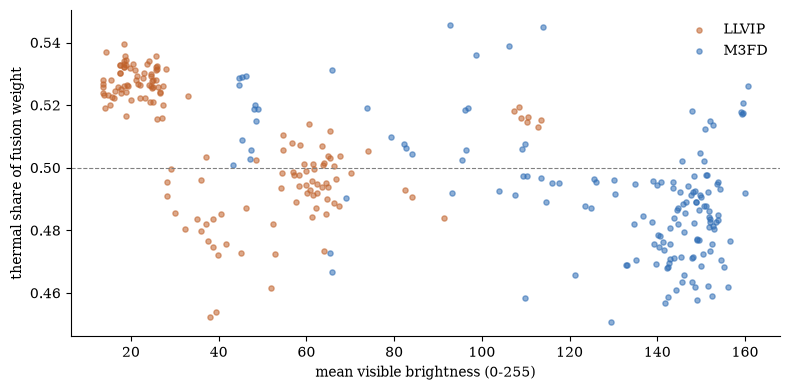

In [6]:
import cv2, matplotlib.pyplot as plt
from cffm.viz import reliability_maps
rng = np.random.default_rng(0)
pts = {}
for name in ("llvip", "m3fd"):
    files = sorted((env.data / name / "images" / "visible" / "val").glob("*.jpg"))
    xs, ys = [], []
    for f in rng.choice(files, size=min(150, len(files)), replace=False):
        pair = make_pair(str(f))
        share = hud.trust_share(reliability_maps(cffm[name], pair)[0], pair.shape)
        xs.append(cv2.cvtColor(pair[..., :3], cv2.COLOR_BGR2GRAY).mean())
        ys.append(float(share.mean()))
    pts[name] = (np.array(xs), np.array(ys))
plt.rcParams.update({"font.family": "serif", "axes.spines.top": False, "axes.spines.right": False})
fig, ax = plt.subplots(figsize=(8, 4))
for name, col in (("llvip", "#C0622B"), ("m3fd", "#2F6DB5")):
    x, y = pts[name]
    ax.scatter(x, y, s=14, alpha=0.55, color=col, label=name.upper())
    print(f"{name}: mean thermal share {y.mean():.3f}; corr(brightness, share) = {np.corrcoef(x, y)[0, 1]:+.2f}")
ax.axhline(0.5, color="gray", lw=0.8, ls="--")
ax.set_xlabel("mean visible brightness (0-255)"); ax.set_ylabel("thermal share of fusion weight")
ax.legend(frameon=False); plt.tight_layout(); plt.savefig(out / "trust_vs_brightness.png", dpi=200); plt.show()

## 5. When a camera fails

The same night scene under four conditions, CFFM-Net on the left and the concat baseline on the right. For the dropped thermal camera, CFFM-Net is told which sensor is gone through its availability flag; concat has no way to use that.

clean                      CFFM-NET  8 subjects


clean                      CONCAT    10 subjects


visible camera off         CFFM-NET  9 subjects


visible camera off         CONCAT    8 subjects


thermal camera off         CFFM-NET  0 subjects


thermal camera off         CONCAT    0 subjects


thermal misaligned 8 px    CFFM-NET  8 subjects


thermal misaligned 8 px    CONCAT    10 subjects


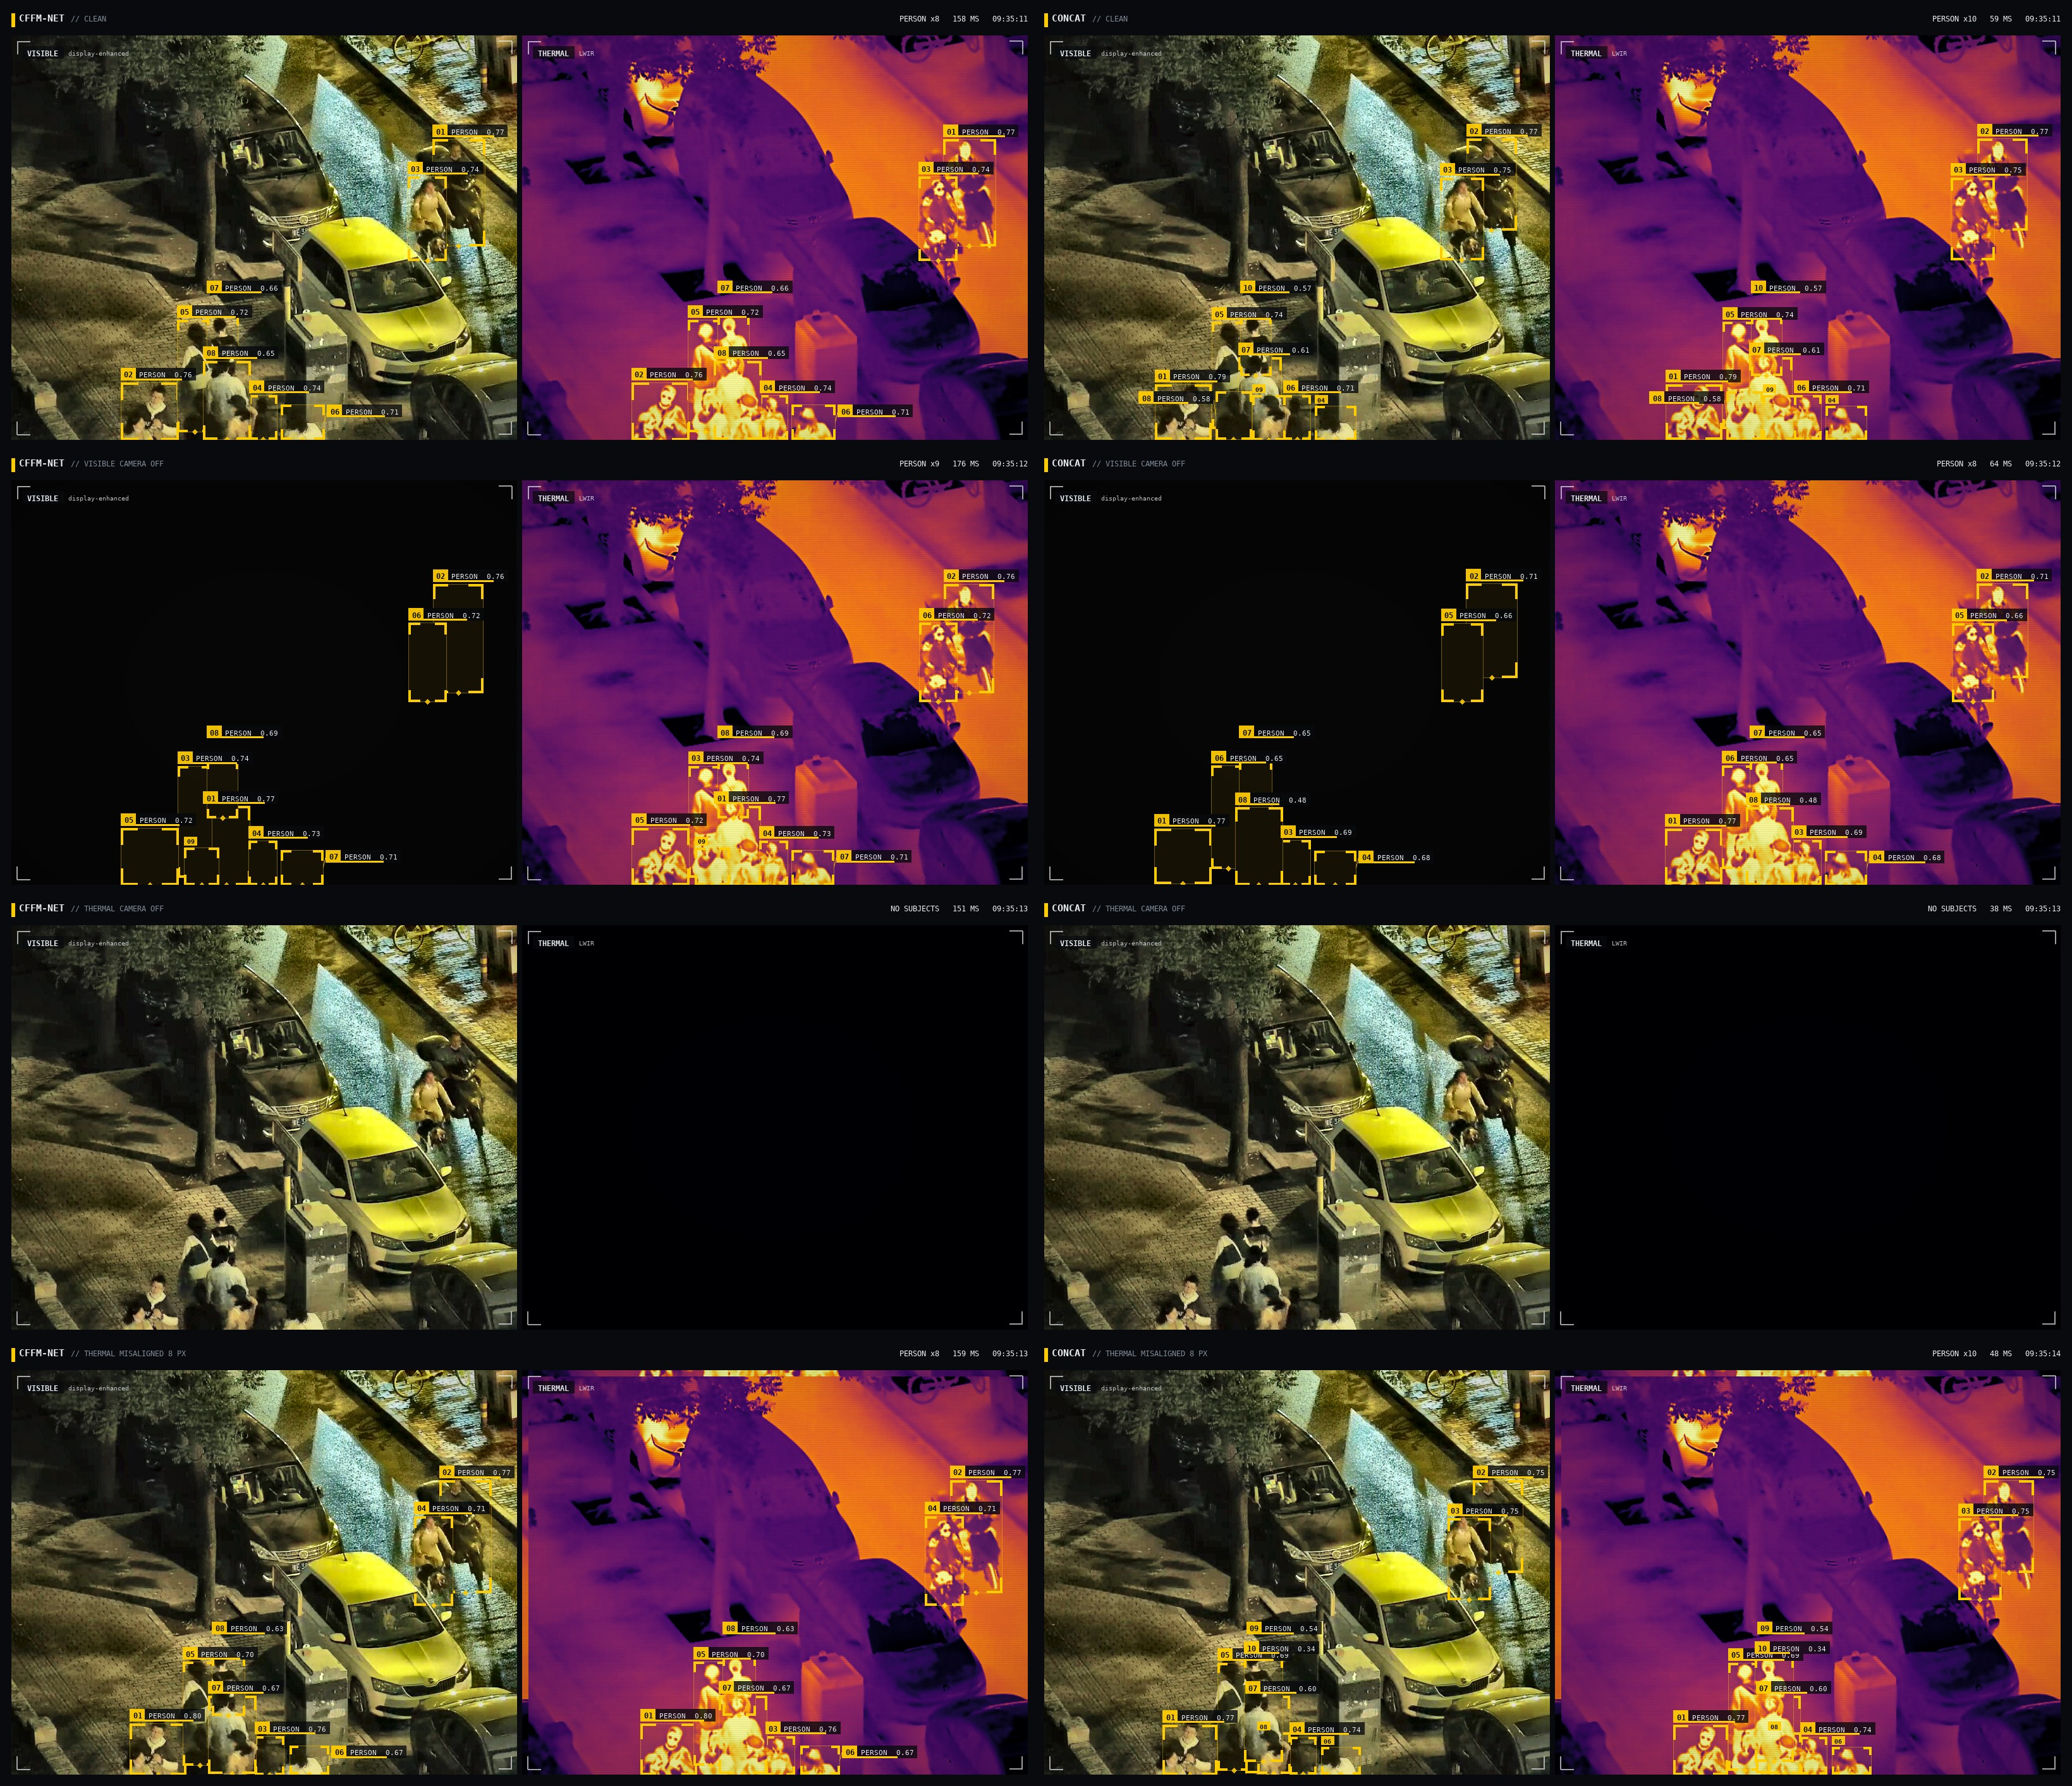

In [7]:
stem = sc.crowded(env.data / "llvip", k=2)[1]
pair = make_pair(*sc.pair_paths(env, "llvip", stem))
cases = [("clean", None, None), ("visible camera off", "visible_drop", [[0.0, 1.0]]),
         ("thermal camera off", "thermal_drop", [[1.0, 0.0]]), ("thermal misaligned 8 px", "thermal_shift", None)]
boards = []
for title, kind, flags in cases:
    p = pair if kind is None else sc.degrade(pair, kind)
    for model, label in ((cffm["llvip"], "CFFM-NET"), (concat, "CONCAT")):
        model.sensor_flags = None if flags is None or model is concat else torch.tensor(flags)
        a = hud.analyze(model, p, panels=("visible", "thermal"), title=label, subtitle=title.upper())
        model.sensor_flags = None
        boards.append(a.board)
        print(f"{title:26s} {label:9s} {len(a.det)} subjects")
sc.show(hud.grid(boards, cols=2))
_ = sc.save(hud.grid(boards, cols=2), out / "sensor_failures.jpg")

## 6. Tracking a crowd

LLVIP's test frames are sampled seconds apart, with different people in each, so they cannot be tracked. Tracking needs real video: MOT17-04, a pedestrian street at night filmed at 30 fps (MOT Challenge, CC BY-NC-SA 3.0). The footage is visible only, so it goes to the general YOLO26-n at 1280 px. Each subject keeps its number, a trail of where it walked and an arrow for where it is heading.

150 frames (10 s at 15 fps), 72 track IDs; saved tracking_mot17.mp4, tracking_mot17.gif


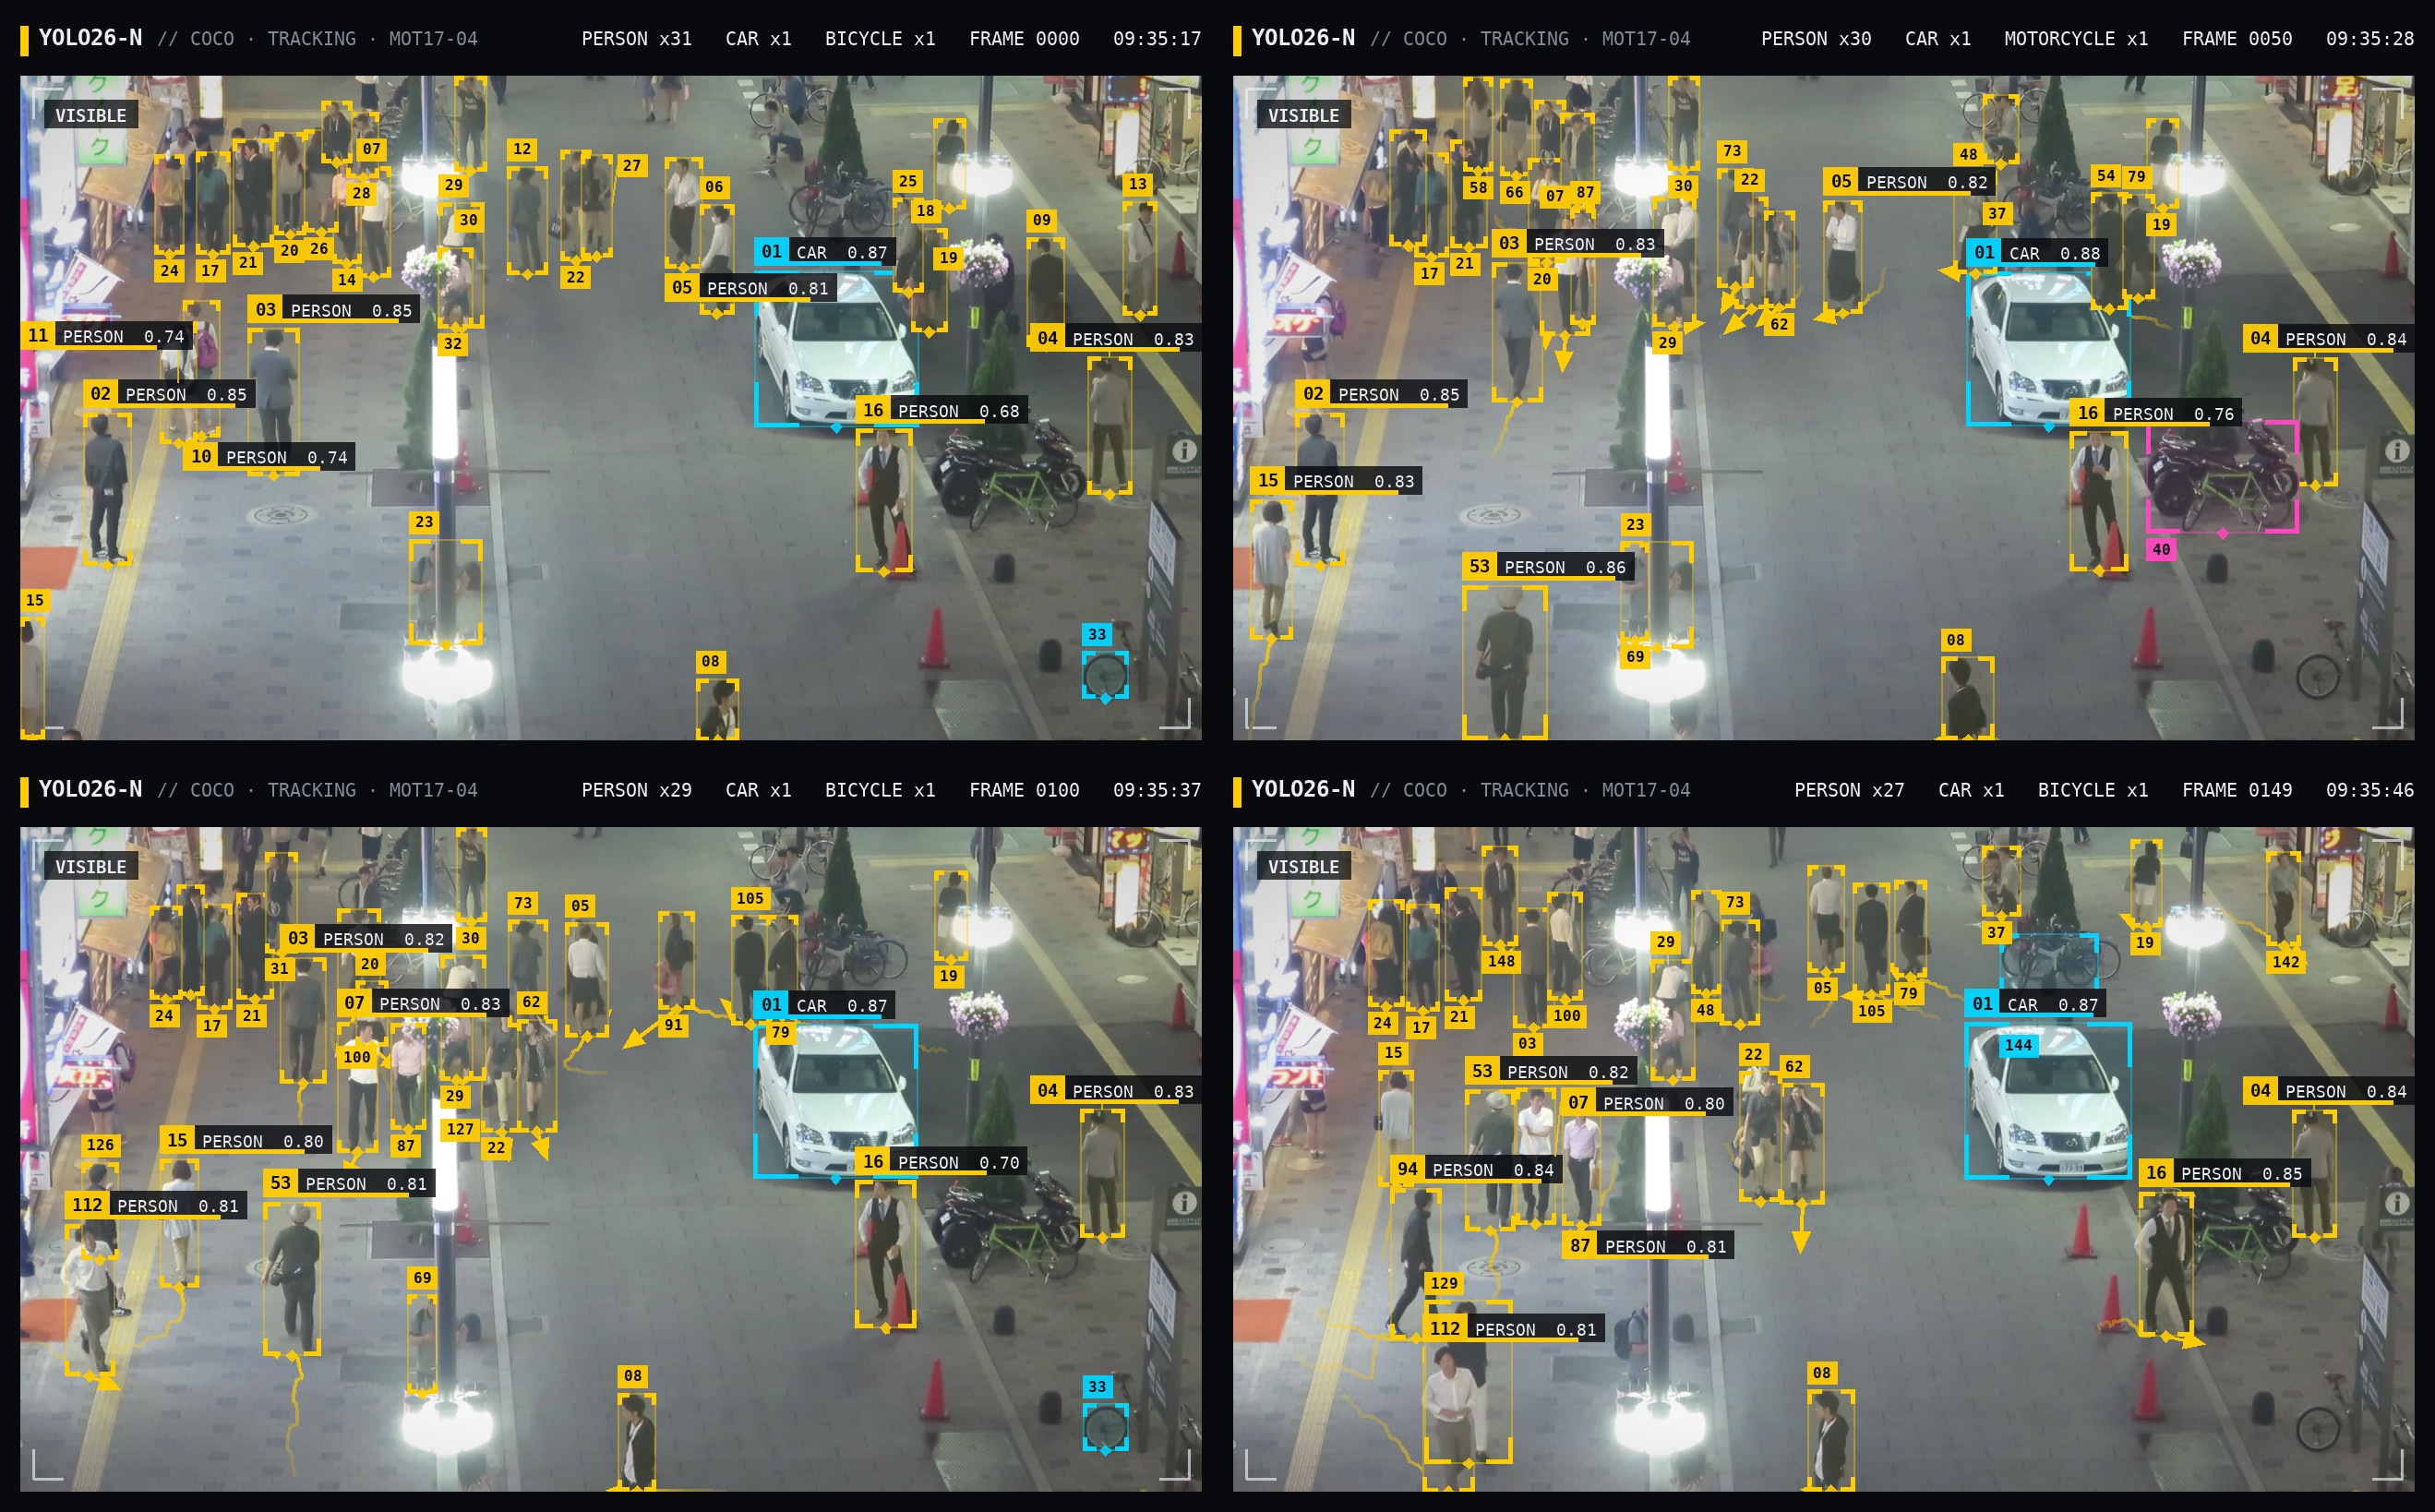

In [8]:
seq = sc.find_sequence(env, "MOT17-04")
frames = sorted(seq.glob("*.jpg"))[:300:2]
boards, n_ids = sc.track(coco, frames, title="YOLO26-N", subtitle="COCO · TRACKING · MOT17-04", panel_w=1280)
mp4 = hud.save_video(boards, out / "tracking_mot17.mp4", fps=15, width=1600)
gif = hud.save_video(boards[::3], out / "tracking_mot17.gif", fps=5, width=760)
print(f"{len(frames)} frames (10 s at 15 fps), {n_ids} track IDs; saved {Path(mp4).name}, {Path(gif).name}")
sc.show(hud.grid([boards[i] for i in (0, len(boards) // 3, 2 * len(boards) // 3, len(boards) - 1)], cols=2))

## 7. Any photo

CFFM-Net needs a visible and a thermal camera. For an ordinary photo we use the general YOLO26-n trained on COCO's 80 classes, drawn the same way and labelled as such.

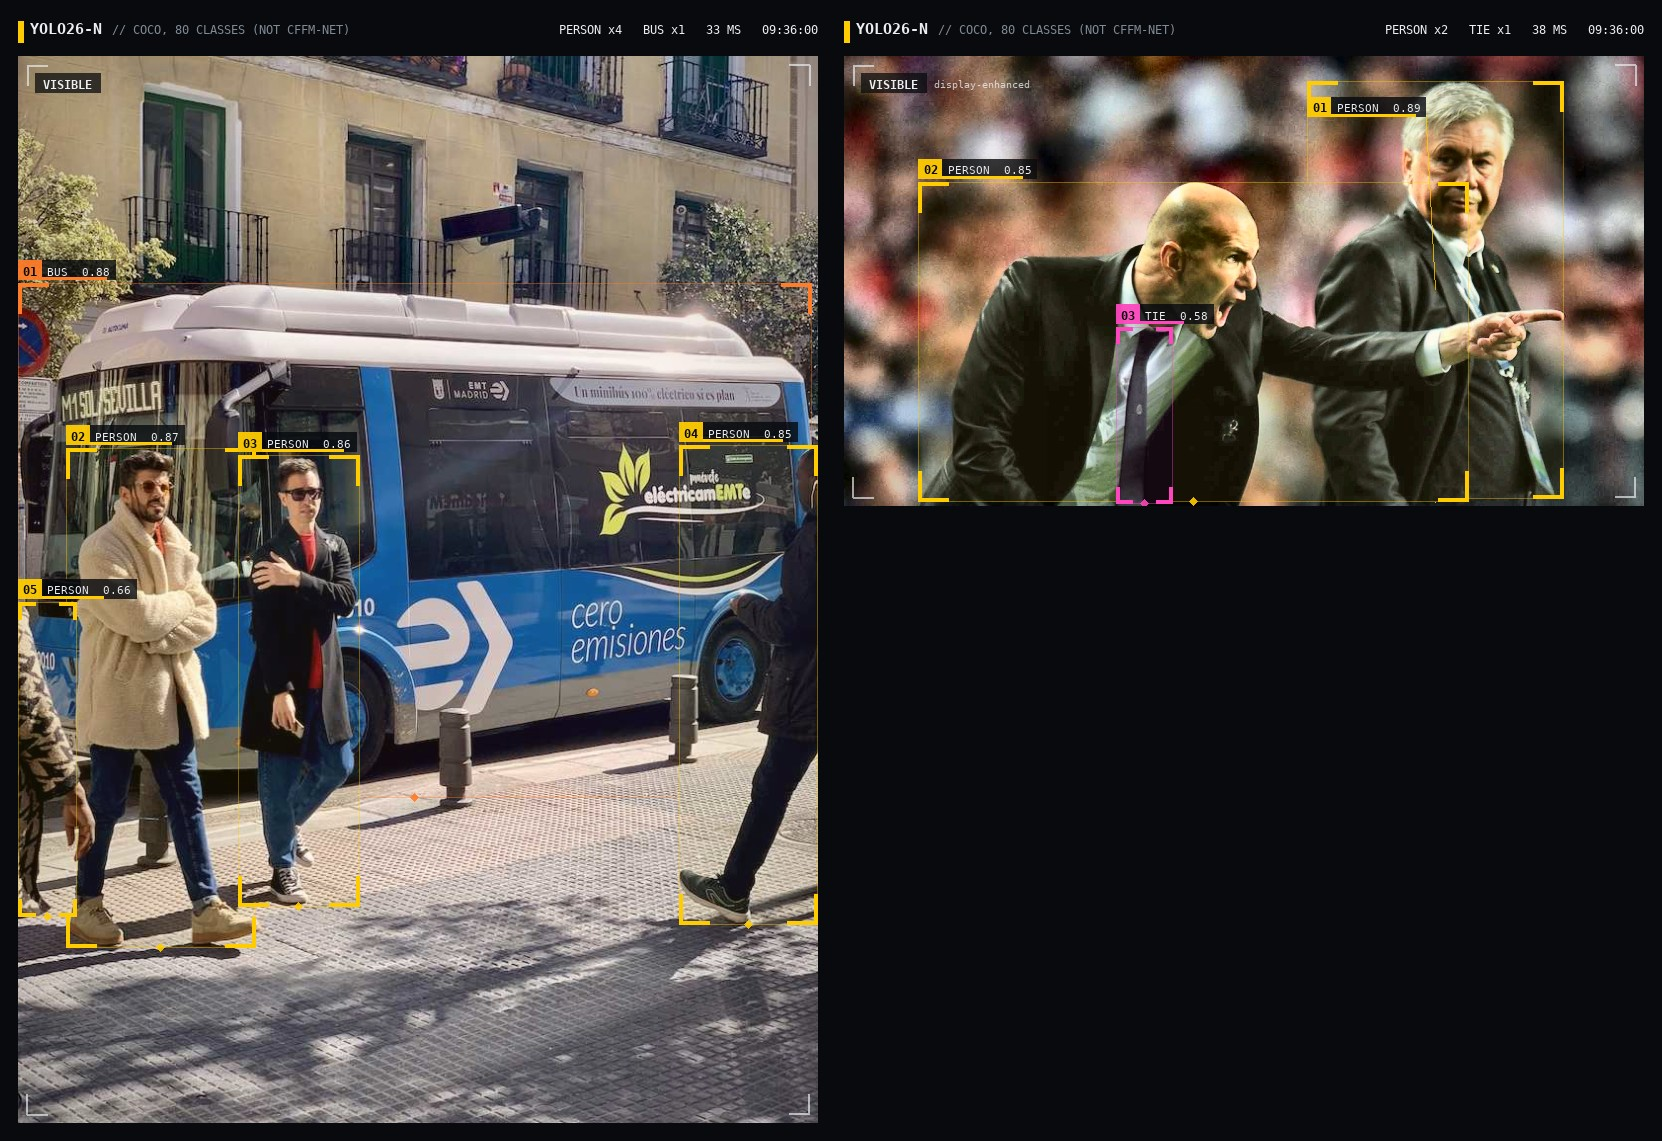

In [9]:
from ultralytics.utils import ASSETS
boards = []
for f in sorted(ASSETS.glob("*.jpg")) + sorted((env.project / "demo" / "samples").glob("*.jpg")):
    a = hud.analyze(coco, f, title="YOLO26-N", subtitle="COCO, 80 CLASSES (NOT CFFM-NET)")
    sc.save(a.board, out / f"photo_{f.stem}.jpg")
    boards.append(a.board)
sc.show(hud.grid(boards, cols=len(boards)))

## 8. Your own images

Set the paths and run: a visible + thermal pair goes to CFFM-Net, a single photo to the COCO model. Running interactively, the upload box below does the same.

In [10]:
MY_VISIBLE, MY_THERMAL, MY_PHOTO = "", "", ""
if MY_VISIBLE and MY_THERMAL:
    sc.show(hud.analyze(cffm["llvip"], MY_VISIBLE, MY_THERMAL).board)
if MY_PHOTO:
    sc.show(hud.analyze(coco, MY_PHOTO, title="YOLO26-N", subtitle="COCO, 80 CLASSES").board)
try:
    import ipywidgets as w
    from IPython.display import display
    up = w.FileUpload(accept="image/*", multiple=True, description="upload")
    def on_upload(change):
        files = [np.frombuffer(bytes(f["content"]), np.uint8) for f in up.value]
        ims = [cv2.imdecode(b, cv2.IMREAD_COLOR) for b in files]
        a = hud.analyze(cffm["llvip"], ims[0], cv2.cvtColor(ims[1], cv2.COLOR_BGR2GRAY)) if len(ims) == 2 else \
            hud.analyze(coco, ims[0], title="YOLO26-N", subtitle="COCO, 80 CLASSES")
        sc.show(a.board)
    up.observe(on_upload, names="value")
    display(up)
except ImportError:
    print("ipywidgets not installed; use the paths above")

FileUpload(value=(), accept='image/*', description='upload', multiple=True)